In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import norm
import xgboost as xgb
from scipy.stats import norm

# Notebook to reproduce results from simulation of two SNPs (Experiment 1) 

## Utils

In [2]:
def _as_two_mafs(maf):
    maf = np.asarray(maf, dtype=float)
    if maf.ndim == 0:
        return np.array([float(maf), float(maf)])
    if len(maf) != 2:
        raise ValueError("maf must be a scalar or length-2 iterable, e.g. 0.3 or (0.2, 0.4)")
    return maf


def simulate_snps(n, maf=0.3, ld=0.0, rng=None, pure_gaussian: bool = False):
    rng = np.random.default_rng(rng)
    maf = _as_two_mafs(maf)

    if ld == 0.0:
        x1 = rng.binomial(2, maf[0], size=n)
        x2 = rng.binomial(2, maf[1], size=n)
        return np.column_stack([x1, x2])

    corr = np.array([[1.0, ld], [ld, 1.0]])
    if pure_gaussian:
        return rng.multivariate_normal(
            mean=[0.0, 0.0],
            cov=corr,
            size=n,
        )
    else:
        z = rng.multivariate_normal([0.0, 0.0], corr, size=n)

        u = norm.cdf(z)
        snps = np.zeros_like(u, dtype=int)
        for j in range(2):
            p = maf[j]
            p0 = (1 - p) ** 2
            p1 = 2 * p * (1 - p)

            t0 = p0
            t1 = p0 + p1

            snps[:, j] = 0
            snps[u[:, j] > t0, j] = 1
            snps[u[:, j] > t1, j] = 2

    return snps

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


def simulate_snps_with_latent(n, maf=0.3, ld=0.0, rng=None):
    rng = np.random.default_rng(rng)
    maf = _as_two_mafs(maf)

    corr = np.array([[1.0, ld], [ld, 1.0]])
    z = rng.multivariate_normal([0.0, 0.0], corr, size=n)

    u = norm.cdf(z)
    snps = np.zeros_like(u, dtype=int)

    for j in range(2):
        p = maf[j]
        p0 = (1 - p) ** 2
        p1 = 2 * p * (1 - p)

        snps[:, j] = 0
        snps[u[:, j] > p0, j] = 1
        snps[u[:, j] > p0 + p1, j] = 2

    return z, snps


def third_order_moments(X, standardize=True):
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=0)

    if standardize:
        sd = Xc.std(axis=0, ddof=0)
        Xc = Xc / sd

    x1, x2 = Xc[:, 0], Xc[:, 1]

    return {
        "E[x1^3]": np.mean(x1**3),
        "E[x1^2 x2]": np.mean(x1**2 * x2),
        "E[x1 x2^2]": np.mean(x1 * x2**2),
        "E[x2^3]": np.mean(x2**3),
    }


def scan_ld_maf(
    n=100_000,
    mafs=np.linspace(0.05, 0.5, 10),
    lds=np.linspace(-0.9, 0.9, 19),
    seed=0,
):
    records = []

    for maf in mafs:
        for ld in lds:
            z, snps = simulate_snps_with_latent(
                n=n,
                maf=(maf, maf),
                ld=ld,
                rng=seed,
            )

            for source, X in {
                "latent": z,
                "thresholded": snps,
            }.items():
                moments = third_order_moments(X, standardize=True)

                for moment, value in moments.items():
                    records.append({
                        "maf": maf,
                        "ld": ld,
                        "source": source,
                        "moment": moment,
                        "value": value,
                    })

    return pd.DataFrame(records)


df = scan_ld_maf(
    n=200_000,
    mafs=np.linspace(0.05, 0.5, 10),
    lds=np.linspace(0.0, 0.9, 18),
    seed=42,
)

In [4]:
def plot_cross_moment_heatmap(
    df,
    source="thresholded",
    moment="E[x1^2 x2]",
    figsize=(9, 5),
    label_fontsize=14,
    tick_fontsize=12,
    cbar_label_fontsize=14,
    cbar_tick_fontsize=12,
    save_path=None,
    dpi=300,
):
    sub = df[
        (df["source"] == source) &
        (df["moment"] == moment)
    ]

    mat = sub.pivot(index="maf", columns="ld", values="value")

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        mat.values,
        aspect="auto",
        origin="lower",
        extent=[
            mat.columns.min(),
            mat.columns.max(),
            mat.index.min(),
            mat.index.max(),
        ],
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("standardized third cross moment", fontsize=cbar_label_fontsize)
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    ax.set_xlabel("LD", fontsize=label_fontsize)
    ax.set_ylabel("MAF", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, format="pdf", bbox_inches="tight", dpi=dpi)

    plt.show()

    return fig, ax

In [6]:
def center_train_test(X_train, X_test, center_snps=True, return_mean=False):
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)

    if not center_snps:
        mean = np.zeros((1, X_train.shape[1]))
        if return_mean:
            return X_train, X_test, mean
        return X_train, X_test

    mean = X_train.mean(axis=0, keepdims=True)

    X_train_c = X_train - mean
    X_test_c = X_test - mean

    if return_mean:
        return X_train_c, X_test_c, mean

    return X_train_c, X_test_c

In [7]:
def generate_phenotype_from_design(
    X_design,
    h_add,
    h_epi,
    beta_add=(1.0, 1.0),
    beta_epi=1.0,
    rng=None,
    add_noise=True,
    return_components=False,
):
    rng = np.random.default_rng(rng)

    additive_raw = X_design @ np.asarray(beta_add)
    epistatic_raw = beta_epi * X_design[:, 0] * X_design[:, 1]

    additive_std = np.std(additive_raw)
    epistatic_std = np.std(epistatic_raw)

    additive = additive_raw / additive_std
    epistatic = epistatic_raw / epistatic_std

    genetic = np.sqrt(h_add) * additive + np.sqrt(h_epi) * epistatic

    if add_noise:
        noise_var = max(1.0 - h_add - h_epi, 0.0)
        noise = rng.normal(0.0, np.sqrt(noise_var), size=X_design.shape[0])
        y = genetic + noise
    else:
        y = genetic

    if return_components:
        return y, {
            "additive_std": additive_std,
            "epistatic_std": epistatic_std,
            "beta_add": np.asarray(beta_add),
            "beta_epi": beta_epi,
        }

    return y

In [8]:
def apply_phenotype_from_params(
    X_design,
    h_add,
    h_epi,
    phenotype_params,
    rng=None,
    add_noise=True,
):
    rng = np.random.default_rng(rng)

    additive_raw = X_design @ phenotype_params["beta_add"]
    epistatic_raw = phenotype_params["beta_epi"] * X_design[:, 0] * X_design[:, 1]

    additive = additive_raw / phenotype_params["additive_std"]
    epistatic = epistatic_raw / phenotype_params["epistatic_std"]

    genetic = np.sqrt(h_add) * additive + np.sqrt(h_epi) * epistatic

    if not add_noise:
        return genetic

    noise_var = max(1.0 - h_add - h_epi, 0.0)
    noise = rng.normal(0.0, np.sqrt(noise_var), size=X_design.shape[0])

    return genetic + noise

In [34]:
def make_train_test_data(
    n_train,
    n_test,
    h_add,
    h_epi,
    maf=0.3,
    ld=0.0,
    center_snps=True,
    rng=None,
    return_center_mean=False,
    add_noise=True,
    beta_add=(1.0, 1.0),
    beta_epi=1.0
):
    rng = np.random.default_rng(rng)

    X_train_raw = simulate_snps(n_train, maf=maf, ld=ld, rng=rng)
    X_test_raw = simulate_snps(n_test, maf=maf, ld=ld, rng=rng)

    X_train, X_test, center_mean = center_train_test(
        X_train_raw,
        X_test_raw,
        center_snps=center_snps,
        return_mean=True,
    )

    y_train, phenotype_params = generate_phenotype_from_design(
        X_train,
        h_add=h_add,
        h_epi=h_epi,
        beta_add=beta_add,
        beta_epi=beta_epi,
        rng=rng,
        add_noise=add_noise,
        return_components=True,
    )

    y_test = apply_phenotype_from_params(
        X_test,
        h_add=h_add,
        h_epi=h_epi,
        phenotype_params=phenotype_params,
        rng=rng,
        add_noise=add_noise,
    )

    if return_center_mean:
        return X_train, X_test, y_train, y_test, center_mean, phenotype_params

    return X_train, X_test, y_train, y_test

In [10]:
def preprocess_snps(X_train, X_test, center_snps=True):
    X_train = X_train.astype(float)
    X_test = X_test.astype(float)

    if center_snps:
        mean = X_train.mean(axis=0, keepdims=True)
        X_train = X_train - mean
        X_test = X_test - mean

    return X_train, X_test

In [11]:
def fit_and_score(X_train, X_test, y_train, y_test, center_snps=True, tree_depth: int = 2):
    X_train_fit, X_test_fit = preprocess_snps(
        X_train,
        X_test,
        center_snps=center_snps,
    )

    linear = LinearRegression()
    tree = DecisionTreeRegressor(max_depth=tree_depth, random_state=0)

    linear.fit(X_train_fit, y_train)
    tree.fit(X_train_fit, y_train)

    mse_linear = mean_squared_error(y_test, linear.predict(X_test_fit))
    mse_tree = mean_squared_error(y_test, tree.predict(X_test_fit))

    return mse_linear, mse_tree

In [38]:
def random_beta_add(rng, p=2):
    beta = rng.normal(size=p)
    beta /= np.linalg.norm(beta)
    return beta

def random_beta_epi(rng):
    return rng.normal()

In [43]:
def run_experiment_by_tree_depth(
    tree_depths=(2, 3, 4),
    n_train=1000,
    n_test=1000,
    n_repeats=100,
    h_add=0.3,
    h_epi_values=None,
    maf=0.3,
    ld=0.0,
    center_snps=True,
    seed=0,
    add_noise=True
):
    if h_epi_values is None:
        h_epi_values = np.round(np.arange(0.0, 0.3001, 0.03), 2)

    rng = np.random.default_rng(seed)
    all_results = {}

    for depth in tree_depths:
        depth_results = {}

        for h_epi in h_epi_values:
            deltas = []

            for _ in range(n_repeats):
                beta_add = random_beta_add(rng)
                beta_epi = random_beta_epi(rng)
                X_train, X_test, y_train, y_test = make_train_test_data(
                    n_train=n_train,
                    n_test=n_test,
                    h_add=h_add,
                    h_epi=h_epi,
                    maf=maf,
                    ld=ld,
                    center_snps=center_snps,
                    rng=rng,
                    add_noise=add_noise,
                    beta_add=beta_add,
                    beta_epi=beta_epi
                )

                linear = LinearRegression()
                tree = DecisionTreeRegressor(max_depth=depth, random_state=int(rng.integers(1e9)))

                linear.fit(X_train, y_train)
                tree.fit(X_train, y_train)

                mse_linear = mean_squared_error(y_test, linear.predict(X_test))
                mse_tree = mean_squared_error(y_test, tree.predict(X_test))

                deltas.append(mse_linear - mse_tree)

            depth_results[h_epi] = np.asarray(deltas)

        all_results[depth] = depth_results

    return all_results

In [44]:
def plot_delta_mse_by_tree_depth(
    all_results,
    output_path=None,
    label_fontsize=16,
    figsize=(10, 5),
):
    fig, ax = plt.subplots(figsize=figsize)

    for depth, results in all_results.items():
        h_epi_values = np.array(sorted(results.keys()))
        means = np.array([results[h].mean() for h in h_epi_values])
        stds = np.array([results[h].std() for h in h_epi_values])

        ax.plot(
            h_epi_values,
            means,
            marker="o",
            label=f"Tree depth {depth}",
        )

        ax.fill_between(
            h_epi_values,
            means - stds,
            means + stds,
            alpha=0.2,
        )

    ax.axhline(0, linestyle="--", color="black")

    ax.set_xlabel(r"Epistatic heritability $h^2_{epi}$", fontsize=label_fontsize)
    ax.set_ylabel(r"$\Delta$MSE = MSE$_{linear}$ - MSE$_{tree}$", fontsize=label_fontsize)

    ax.set_xticks(np.round(np.arange(0.0, 0.3001, 0.05), 2))
    ax.tick_params(axis="both", labelsize=label_fontsize)

    ax.legend(fontsize=label_fontsize - 4)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [19]:
def run_ld_experiment(
    ld_values=(0.0, 0.25, 0.5, 0.75),
    h_epi_values=None,
    n_train=1000,
    n_test=1000,
    n_repeats=100,
    h_add=0.3,
    maf=0.3,
    center_snps=True,
    seed=42,
    tree_depth: int = 2,
    add_noise=True
):
    if h_epi_values is None:
        h_epi_values = np.round(np.arange(0.0, 0.3001, 0.03), 2)

    rng = np.random.default_rng(seed)
    results = {}

    for ld in ld_values:
        ld_results = {}

        for h_epi in h_epi_values:
            deltas = []

            for _ in range(n_repeats):
                X_train, X_test, y_train, y_test = make_train_test_data(
                    n_train=n_train,
                    n_test=n_test,
                    h_add=h_add,
                    h_epi=h_epi,
                    maf=maf,
                    ld=ld,
                    center_snps=center_snps,
                    rng=rng,
                    add_noise=add_noise
                )

                mse_linear, mse_tree = fit_and_score(
                    X_train,
                    X_test,
                    y_train,
                    y_test,
                    tree_depth=tree_depth
                )

                deltas.append(mse_linear - mse_tree)

            ld_results[h_epi] = np.asarray(deltas)

        h_vals = np.array(list(ld_results.keys()))
        mean_deltas = np.array([ld_results[h].mean() for h in h_vals])

        delta_h_corr = np.corrcoef(h_vals, mean_deltas)[0, 1]

        results[ld] = {
            "deltas": ld_results,
            "delta_h_corr": delta_h_corr,
        }

    return results

In [20]:
def plot_ld_mean_variance(
    results,
    variance="std",
    output_path=None,
    label_fontsize: int = 16,
    legend_fontsize: int = 14,
    figsize = (10, 6)
):
    """
    variance:
        "std" -> mean +/- standard deviation
        "sem" -> mean +/- standard error
        "var" -> mean +/- variance
    """
    plt.figure(figsize=figsize)

    for ld, ld_result in results.items():
        deltas_by_h = ld_result["deltas"]
        h_epi_values = np.array(list(deltas_by_h.keys()))

        means = np.array([deltas_by_h[h].mean() for h in h_epi_values])
        stds = np.array([deltas_by_h[h].std(ddof=1) for h in h_epi_values])
        ns = np.array([len(deltas_by_h[h]) for h in h_epi_values])

        if variance == "std":
            spread = stds
        elif variance == "sem":
            spread = stds / np.sqrt(ns)
        elif variance == "var":
            spread = stds**2
        else:
            raise ValueError("variance must be one of: 'std', 'sem', 'var'")

        label = rf"$r = {ld}$"

        line = plt.plot(
            h_epi_values,
            means,
            marker="o",
            linewidth=2,
            label=label,
        )[0]

        color = line.get_color()

        plt.fill_between(
            h_epi_values,
            means - spread,
            means + spread,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    plt.axhline(0, linestyle="--", linewidth=2)

    plt.xlabel(r"Epistatic heritability $h^2_{\mathrm{epi}}$", fontsize=label_fontsize)
    plt.ylabel(r"$\Delta$MSE = MSE$_{\mathrm{linear}}$ - MSE$_{\mathrm{tree}}$", fontsize=label_fontsize)

    plt.legend(title="LD", fontsize=legend_fontsize, title_fontsize=legend_fontsize * 1.2)
    plt.xticks(fontsize=label_fontsize)
    plt.yticks(fontsize=label_fontsize)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [311]:
def format_mean_std(mean_mat, std_mat):
    return np.asarray([
        [f"{mean_mat[i, j]:.2f}\n±{std_mat[i, j]:.2f}" for j in range(3)]
        for i in range(3)
    ])
    
def run_average_epistasis_example(
    n_runs=100,
    n_train=5000,
    n_test=5000,
    h_add=0.1,
    h_epi=0.3,
    maf=0.3,
    ld=0.0,
    center_snps=True,
    tree_max_depth=2,
    seed=0,
    annotate="squared_error",
    pred_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_pred_heatmap.pdf",
    shap_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_shap_heatmap.pdf",
    add_noise=True,
    color_by="test_mse"
):
    rng = np.random.default_rng(seed)

    true_signals = []
    pred_linears = []
    pred_trees = []

    linear_tile_mses = []
    tree_tile_mses = []

    shap_snp1s = []
    shap_snp2s = []
    shap_epis = []

    mse_linears = []
    mse_trees = []

    last_tree = None
    last_center_mean = None

    for _ in range(n_runs):
        run_seed = int(rng.integers(0, 1_000_000_000))

        X_train, X_test, y_train, y_test, center_mean, phenotype_params = make_train_test_data(
            n_train=n_train,
            n_test=n_test,
            h_add=h_add,
            h_epi=h_epi,
            maf=maf,
            ld=ld,
            center_snps=center_snps,
            rng=run_seed,
            return_center_mean=True,
            add_noise=add_noise
        )

        linear = LinearRegression()
        tree = DecisionTreeRegressor(max_depth=tree_max_depth, random_state=run_seed)

        linear.fit(X_train, y_train)
        tree.fit(X_train, y_train)

        pred_linear_test = linear.predict(X_test)
        pred_tree_test = tree.predict(X_test)

        mse_linears.append(mean_squared_error(y_test, pred_linear_test))
        mse_trees.append(mean_squared_error(y_test, pred_tree_test))

        grid_raw = genotype_grid().astype(float)

        if center_snps:
            grid = grid_raw - center_mean
            X_test_raw = X_test + center_mean
        else:
            grid = grid_raw
            X_test_raw = X_test

        add_signal = grid @ np.array([1.0, 1.0])
        epi_signal = grid[:, 0] * grid[:, 1]

        add_signal = add_signal / np.std(add_signal)
        epi_signal = epi_signal / np.std(epi_signal)

        true_signal = apply_phenotype_from_params(
            grid,
            h_add=h_add,
            h_epi=h_epi,
            phenotype_params=phenotype_params,
            add_noise=False,
        )

        pred_linear = linear.predict(grid)
        pred_tree = tree.predict(grid)

        linear_tile_mse = tile_weighted_mse_matrix(
            X_raw=X_test_raw,
            y_true=y_test,
            y_pred=pred_linear_test,
        )

        tree_tile_mse = tile_weighted_mse_matrix(
            X_raw=X_test_raw,
            y_true=y_test,
            y_pred=pred_tree_test,
        )

        shap_values, shap_interactions = compute_tree_shap_interactions(tree, grid)

        true_signals.append(true_signal)
        pred_linears.append(pred_linear)
        pred_trees.append(pred_tree)

        linear_tile_mses.append(linear_tile_mse)
        tree_tile_mses.append(tree_tile_mse)

        shap_snp1s.append(shap_interactions[:, 0, 0].reshape(3, 3))
        shap_snp2s.append(shap_interactions[:, 1, 1].reshape(3, 3))
        shap_epis.append(shap_interactions[:, 0, 1].reshape(3, 3))

        last_tree = tree
        last_center_mean = center_mean

    avg_true_signal = np.mean(true_signals, axis=0)
    avg_pred_linear = np.mean(pred_linears, axis=0)
    avg_pred_tree = np.mean(pred_trees, axis=0)

    avg_linear_tile_mse = np.mean(linear_tile_mses, axis=0)
    avg_tree_tile_mse = np.mean(tree_tile_mses, axis=0)

    avg_shap_snp1 = np.mean(shap_snp1s, axis=0)
    avg_shap_snp2 = np.mean(shap_snp2s, axis=0)
    avg_shap_epi = np.mean(shap_epis, axis=0)

    std_true_signal = np.std(true_signals, axis=0)
    std_pred_linear = np.std(pred_linears, axis=0)
    std_pred_tree = np.std(pred_trees, axis=0)

    std_linear_tile_mse = np.std(linear_tile_mses, axis=0)
    std_tree_tile_mse = np.std(tree_tile_mses, axis=0)

    std_shap_snp1 = np.std(shap_snp1s, axis=0)
    std_shap_snp2 = np.std(shap_snp2s, axis=0)
    std_shap_epi = np.std(shap_epis, axis=0)

    print(
        f"Average MSE linear: {np.mean(mse_linears):.3f}; "
        f"Average MSE tree: {np.mean(mse_trees):.3f}; "
        f"Average Delta MSE: {np.mean(mse_linears) - np.mean(mse_trees):.3f}"
    )

    print(
        f"Tile MSE check — linear: {avg_linear_tile_mse.sum():.3f}; "
        f"tree: {avg_tree_tile_mse.sum():.3f}"
    )

    if annotate == "squared_error":
        pred_annotation_strings = [
            format_mean_std(np.zeros((3, 3)), np.zeros((3, 3))),
            format_mean_std(avg_linear_tile_mse, std_linear_tile_mse),
            format_mean_std(avg_tree_tile_mse, std_tree_tile_mse),
        ]
    else:
        pred_annotation_strings = [
            format_mean_std(avg_true_signal.reshape(3, 3), std_true_signal.reshape(3, 3)),
            format_mean_std(avg_pred_linear.reshape(3, 3), std_pred_linear.reshape(3, 3)),
            format_mean_std(avg_pred_tree.reshape(3, 3), std_pred_tree.reshape(3, 3)),
        ]

    plot_epistasis_heatmaps_with_tree_boundaries(
        true_signal=avg_true_signal,
        pred_linear=avg_pred_linear,
        pred_tree=avg_pred_tree,
        tree=last_tree,
        center_mean=last_center_mean,
        pred_heatmap_path=pred_heatmap_path,
        weighted_error_mats=(avg_linear_tile_mse, avg_tree_tile_mse),
        annotation_string_mats=pred_annotation_strings,
        color_by=color_by
    )

    shap_annotation_strings = [
        format_mean_std(avg_shap_snp1, std_shap_snp1),
        format_mean_std(avg_shap_snp2, std_shap_snp2),
        format_mean_std(avg_shap_epi, std_shap_epi),
    ]

    plot_shap_effect_heatmaps(
        shap_snp1_main=avg_shap_snp1,
        shap_snp2_main=avg_shap_snp2,
        shap_epi=avg_shap_epi,
        cmap="viridis",
        shap_heatmap_path=shap_heatmap_path,
        annotation_string_mats=shap_annotation_strings,
    )

    return {
        "avg_true_signal": avg_true_signal,
        "avg_pred_linear": avg_pred_linear,
        "avg_pred_tree": avg_pred_tree,
        "avg_linear_tile_mse": avg_linear_tile_mse,
        "avg_tree_tile_mse": avg_tree_tile_mse,
        "avg_shap_snp1": avg_shap_snp1,
        "avg_shap_snp2": avg_shap_snp2,
        "avg_shap_epi": avg_shap_epi,
        "mse_linears": np.array(mse_linears),
        "mse_trees": np.array(mse_trees),
    }

## Plot 1b

In [45]:
all_results = run_experiment_by_tree_depth(
    tree_depths=(2, 3, 4),
    n_train=8000,
    n_test=2000,
    n_repeats=100,
    h_add=0.5,
    h_epi_values=np.round(np.arange(0.0, 0.3001, 0.03), 2),
    maf=0.2,
    ld=0.0,
    center_snps=True,
    seed=42,
    add_noise=True
)

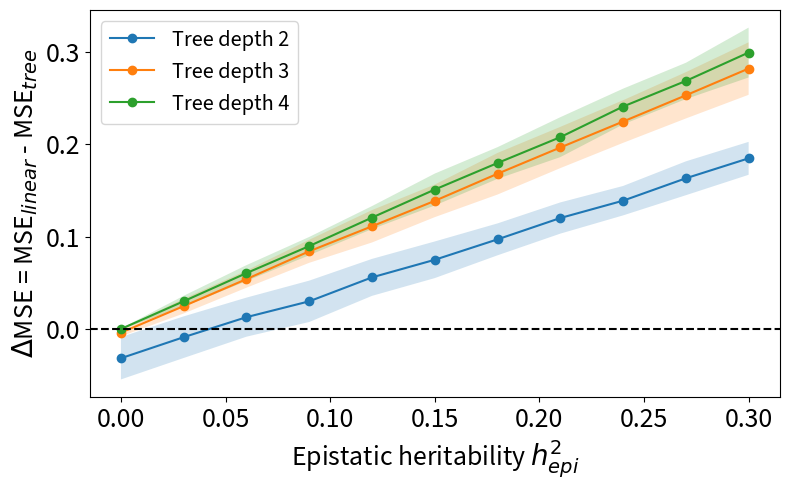

In [46]:
plot_delta_mse_by_tree_depth(
    all_results,
    #output_path="/private/home/cthoma15/genomen/results/plots/delta_mse_by_tree_depth.pdf",
    label_fontsize=20,
    figsize=(8, 5),
)

## Plot 1c

In [ ]:
results = run_ld_experiment(
    ld_values=(0.0, 0.25, 0.5, 0.75),
    h_epi_values=np.round(np.arange(0.0, 0.3001, 0.03), 2),
    n_train=8000,
    n_test=2000,
    n_repeats=100,
    h_add=0.5,
    maf=0.1,
    tree_depth=4,
    center_snps=True,
    seed=42,
    add_noise=True
)

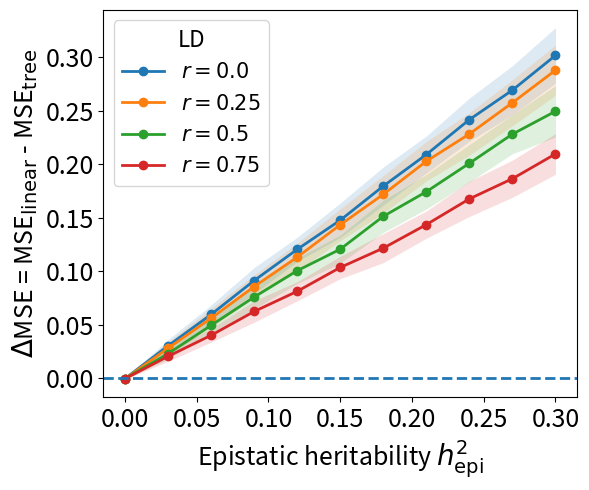

In [22]:
plot_ld_mean_variance(
    results,
    variance="std",
    #output_path="/private/home/cthoma15/genomen/results/plots/delta_mse_by_ld.pdf",
    label_fontsize=20, 
    legend_fontsize=15, 
    figsize=(6,5)
)

## Supplementary plot C2

In [ ]:
results = run_ld_experiment(
    ld_values=(0.0, 0.25, 0.5, 0.75),
    h_epi_values=np.round(np.arange(0.0, 0.3001, 0.03), 2),
    n_train=8000,
    n_test=2000,
    n_repeats=100,
    h_add=0.5,
    maf=0.5,
    tree_depth=4,
    center_snps=True,
    seed=42,
    add_noise=True
)

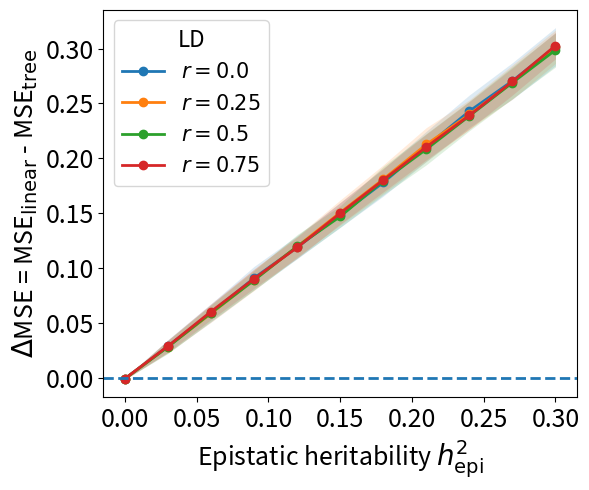

In [25]:
plot_ld_mean_variance(
    results,
    variance="std",
    output_path="/private/home/cthoma15/genomen/results/plots/delta_mse_by_ld_maf05.pdf",
    label_fontsize=20, 
    legend_fontsize=15, 
    figsize=(6,5)
)

## Plot 1d & 1e

Average MSE linear: 0.500; Average MSE tree: 0.400; Average Delta MSE: 0.100
Tile MSE check — linear: 0.500; tree: 0.400


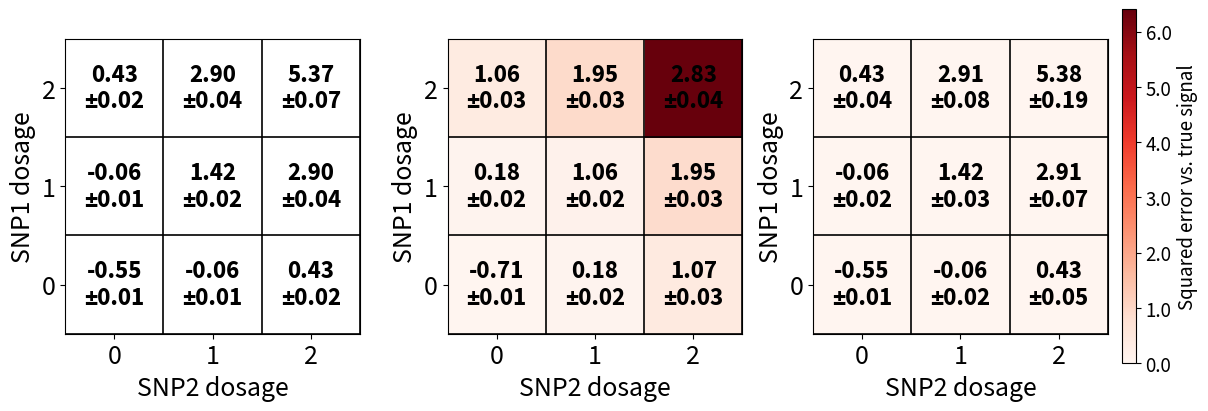

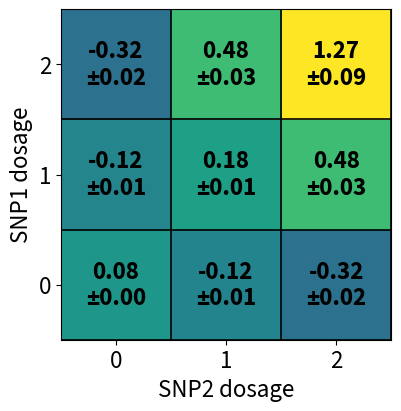

In [322]:
avg_results = run_average_epistasis_example(
    n_runs=100,
    n_train=8000,
    n_test=2000,
    h_add=0.5,
    h_epi=0.1,
    maf=0.2,
    ld=0.0,
    center_snps=True,
    tree_max_depth=4,
    seed=42,
    annotate="value",
    pred_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_pred_heatmap.pdf",
    shap_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_shap_heatmap.pdf",
    add_noise=True,
    color_by="grid_squared_error"
)

## Plot 1f & 1g

Average MSE linear: 0.483; Average MSE tree: 0.400; Average Delta MSE: 0.083
Tile MSE check — linear: 0.483; tree: 0.400


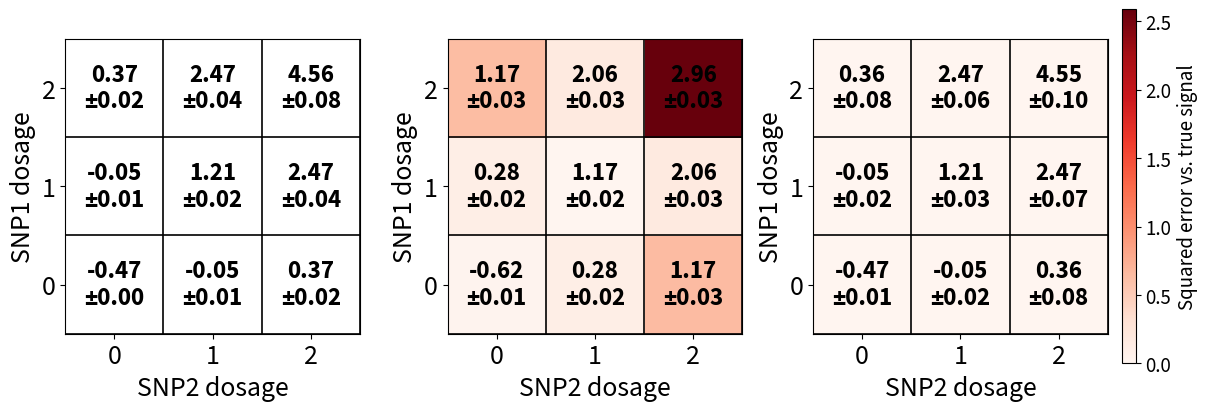

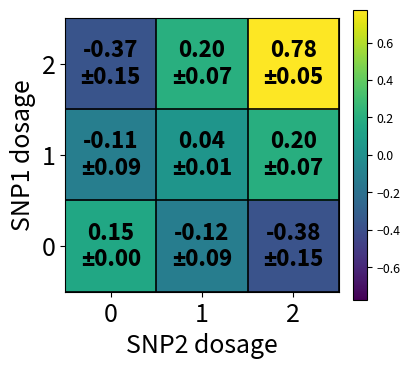

In [313]:
avg_results = run_average_epistasis_example(
    n_runs=100,
    n_train=8000,
    n_test=2000,
    h_add=0.5,
    h_epi=0.1,
    maf=0.2,
    ld=0.5,
    center_snps=True,
    tree_max_depth=4,
    seed=42,
    annotate="value",
    pred_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_ld_pred_heatmap.pdf",
    shap_heatmap_path="/private/home/cthoma15/genomen/results/plots/avg_ld_shap_heatmap.pdf",
    add_noise=True,
    color_by="grid_squared_error"
)

## Supplementary plot C1

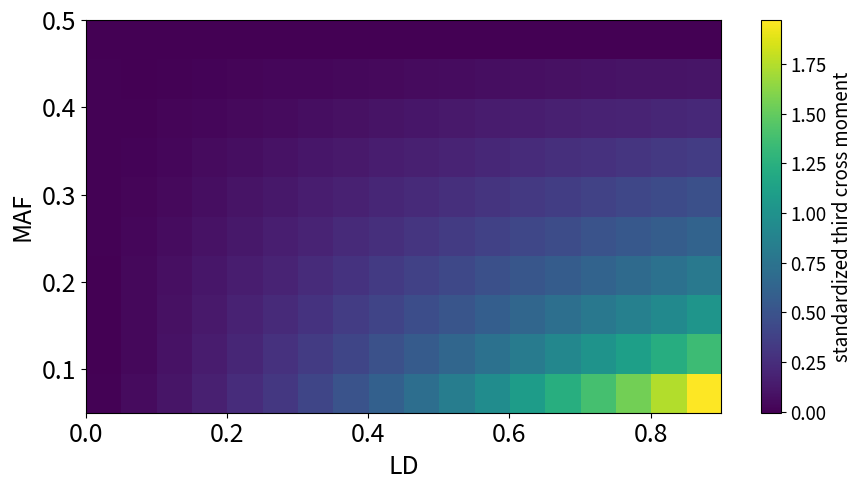

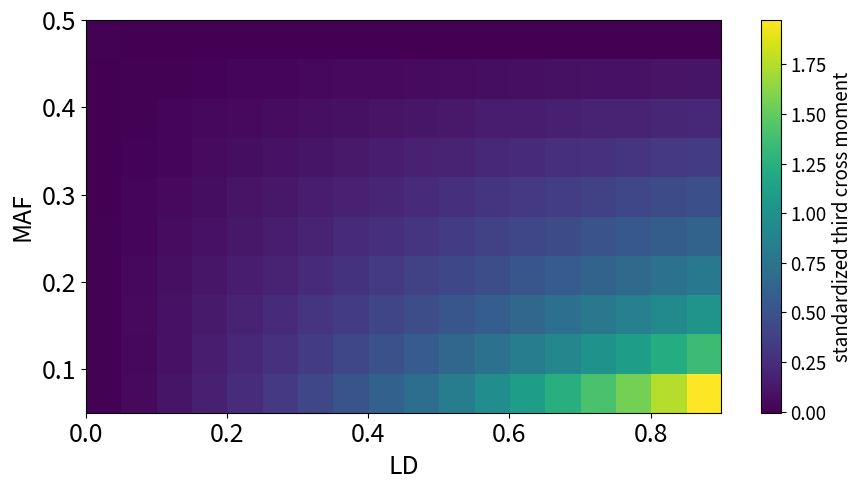

In [5]:
cross_moments = ["E[x1^2 x2]", "E[x1 x2^2]"]

for moment in cross_moments:
    safe_name = (
        moment
        .replace("E[", "")
        .replace("]", "")
        .replace("^", "")
        .replace(" ", "")
    )

    plot_cross_moment_heatmap(
        df,
        source="thresholded",
        moment=moment,
        label_fontsize=20,
        tick_fontsize=20,
        cbar_label_fontsize=15,
        cbar_tick_fontsize=15,
        save_path=f"/private/home/cthoma15/genomen/results/plots/{safe_name}.pdf",
    )